In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pylake

# Pylake propositions of changes:
- Now, Xarray is the main data structure for Pylake, and it is used in all functions. This allows for better integration with other libraries and makes it easier to work with multi-dimensional data.
Explore the conversion in xarray vs using a pandas based libray
- Try to revise all function based on your knowledge in physics and spot some issues. In particular the metalimnion function is coded in a strange way, figure out the math behind it and how it align with the physics of the problem.
- Create a report on all the modifications you made
- Ensure correct formatting of the data. Take into account the fact the normal behavior of a aquatic phyisist using this library. 
- 

In [2]:
df = pd.read_csv(r'C:\Users\cruz\Documents\SENSE\CTD_processing\data\Level1\LacNOX\20250408_Lexplore_spatial\CTD_RBR\236825_20250408_1742\236825_20250408_1742\236825_20250408_1742_data.csv')

In [27]:
df.rename(columns={'temperature_C': 'Temp'}, inplace=True)
df.rename(columns={'Depth': 'depth'}, inplace=True)

In [33]:
ds = df.to_xarray()

In [42]:
#Set "depth" as dimension in ds
ds = ds.set_index(depth='depth')

type: dimension mismatch: try setting an index for dimension 'depth' with variable 'depth' that has dimensions ('index',)

In [64]:
profile1 = df.iloc[0:1500]
profile1.sort_values(by='depth', inplace=True)

C:\Users\cruz\AppData\Local\Temp\ipykernel_26220\530370970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile1.sort_values(by='depth', inplace=True)


<Axes: >

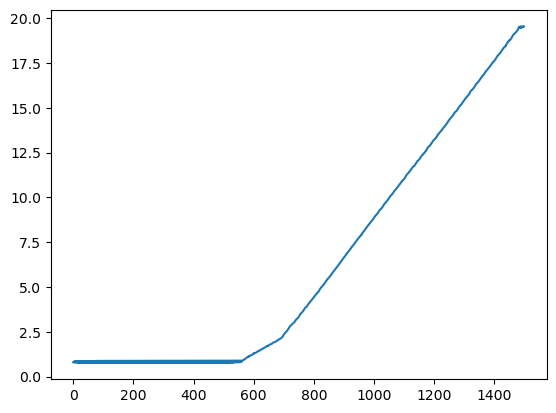

In [65]:
profile1["depth"].plot()

In [67]:
Temp = df["Temp"]
depth = df["depth"]

In [71]:
metalimnion = pylake.thermocline(Temp =df, depth=depth, mixed_cutoff=1, smooth=False, s=0.2)

type: 'DataFrame' object has no attribute 'load'

In [48]:
import pylake
import numpy as np

Temp = np.array([14.3,14,12.1,10,9.7,9.5,6,5])
depth = np.array([1,2,3,4,5,6,7,8])
epilimnion, hypolimnion = pylake.metalimnion(Temp, depth)

In [49]:
epilimnion

2.5

In [ ]:

metalimnion = pylake.thermocline(Temp = df['temperature_C'], depth = df['depth_m'].to_numpy(), seasonal=False, mixed_cutoff=1, smooth=False, s=0.2)